# Task 1A Modelling — Instacart Hybrid Recommendation System

Builds, evaluates, and exports the hybrid recommendation system. Loads preprocessed artefacts from `task1a_preprocessing.ipynb` and produces recommendations, SHAP explanations, evaluation metrics, and fairness diagnostics.

## Google Drive Setup

In [ ]:
from pathlib import Path
from google.colab import drive

# Mount Google Drive so the notebook can read and write files stored there.
drive.mount('/content/drive')

# Update this path to match the location of the project root on your Google Drive.
DRIVE_ROOT = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')

# Paths to preprocessed artefacts, modelling outputs, and the checkpoint file.
PROCESSED       = DRIVE_ROOT / 'data' / 'Task 1' / 'processed'
OUTPUT_DIR      = DRIVE_ROOT / 'data' / 'Task 1' / 'modelling'
CHECKPOINT_PATH = OUTPUT_DIR / 'modelling_checkpoint.json'

# Create the modelling output directory if it does not already exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('DRIVE_ROOT      :', DRIVE_ROOT)
print('PROCESSED       :', PROCESSED)
print('OUTPUT_DIR      :', OUTPUT_DIR)
print('CHECKPOINT_PATH :', CHECKPOINT_PATH)

Mounted at /content/drive
DRIVE_ROOT      : /content/drive/MyDrive/Advanced AI/advanced-ai
PROCESSED       : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1/processed
OUTPUT_DIR      : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1/modelling
CHECKPOINT_PATH : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 1/modelling/modelling_checkpoint.json


## Section 1 — Imports and Configuration

Imports all required libraries and defines configuration constants that control evaluation depth, neighbour count candidates, grid search granularity, and cold-start thresholds.

In [ ]:
import os
import json
import shutil
import datetime
import itertools
import numpy as np
import pandas as pd
import scipy.sparse as sp
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from sklearn.metrics import ndcg_score as sklearn_ndcg_score
import joblib

try:
    import shap
except ImportError:
    # Install shap silently if it is not already present in the Colab environment.
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '--quiet'])
    import shap

# ---------------------------------------------------------------------------
# Configuration constants
# ---------------------------------------------------------------------------
RANDOM_SEED           = 42   # seed for any random operations
K_CANDIDATES          = [5, 10, 20]  # neighbour counts to evaluate in grid search
WEIGHT_STEP           = 0.1  # step size for weight grid; weights are multiples of this
EVAL_K                = [10, 20]  # evaluation depths for precision, recall, NDCG
TOP_N_OUTPUT          = 50   # number of recommendations saved per user
MIN_KNN_INTERACTIONS  = 3    # minimum unique products a user must have for k-NN signal
TOP_N_NEIGHBOURS      = 50   # number of nearest neighbours to pre-compute per user
VALIDATION_MIN_ORDERS = 2    # minimum unique prior orders remaining after holdout

np.random.seed(RANDOM_SEED)

print('RANDOM_SEED           :', RANDOM_SEED)
print('K_CANDIDATES          :', K_CANDIDATES)
print('WEIGHT_STEP           :', WEIGHT_STEP)
print('EVAL_K                :', EVAL_K)
print('TOP_N_OUTPUT          :', TOP_N_OUTPUT)
print('MIN_KNN_INTERACTIONS  :', MIN_KNN_INTERACTIONS)
print('TOP_N_NEIGHBOURS      :', TOP_N_NEIGHBOURS)
print('VALIDATION_MIN_ORDERS :', VALIDATION_MIN_ORDERS)

RANDOM_SEED           : 42
K_CANDIDATES          : [5, 10, 20]
WEIGHT_STEP           : 0.1
EVAL_K                : [10, 20]
TOP_N_OUTPUT          : 50
MIN_KNN_INTERACTIONS  : 3
TOP_N_NEIGHBOURS      : 50
VALIDATION_MIN_ORDERS : 2


## Section 2 — Load Preprocessed Artefacts

Loads all artefacts produced by `task1a_preprocessing.ipynb`. Raises a clear error if any file is missing. Reverse index mappings and a product name lookup dictionary are constructed after loading.

In [ ]:
required_files = [
    PROCESSED / 'user_item_matrix.npz',
    PROCESSED / 'user_item_matrix_normalised.npz',
    PROCESSED / 'product_tfidf_matrix.npz',
    PROCESSED / 'user_content_profiles_normalised.npz',
    PROCESSED / 'knn_model.joblib',
    PROCESSED / 'tfidf_vectoriser.joblib',
    PROCESSED / 'product_index.json',
    PROCESSED / 'user_index.json',
    PROCESSED / 'global_popularity.json',
    PROCESSED / 'filtered_prior.parquet',
    PROCESSED / 'filtered_train.parquet',
    PROCESSED / 'filtered_products.parquet',
]

# Fail early with a clear message if any prerequisite file is absent.
for fpath in required_files:
    if not fpath.exists():
        raise FileNotFoundError(
            f'Required preprocessing artefact not found: {fpath}\n'
            'Run task1a_preprocessing.ipynb before this notebook.'
        )

# Load sparse matrices produced by the preprocessing pipeline.
user_item_matrix           = sp.load_npz(PROCESSED / 'user_item_matrix.npz')
user_item_matrix_norm      = sp.load_npz(PROCESSED / 'user_item_matrix_normalised.npz')
product_tfidf_matrix       = sp.load_npz(PROCESSED / 'product_tfidf_matrix.npz')
user_content_profiles_norm = sp.load_npz(PROCESSED / 'user_content_profiles_normalised.npz')

# Load the fitted k-NN model and TF-IDF vectoriser from disk.
knn_model        = joblib.load(PROCESSED / 'knn_model.joblib')
tfidf_vectoriser = joblib.load(PROCESSED / 'tfidf_vectoriser.joblib')

# Load product and user index mappings (original integer ID -> matrix row/col index).
with open(PROCESSED / 'product_index.json', 'r') as fh:
    product_to_idx = {int(k): v for k, v in json.load(fh).items()}

with open(PROCESSED / 'user_index.json', 'r') as fh:
    user_to_idx = {int(k): v for k, v in json.load(fh).items()}

# Load the global popularity ranking: an ordered list of product IDs by purchase frequency.
with open(PROCESSED / 'global_popularity.json', 'r') as fh:
    global_popularity = [int(pid) for pid in json.load(fh)]

# Load filtered order and product tables.
filtered_prior    = pd.read_parquet(PROCESSED / 'filtered_prior.parquet')
filtered_train    = pd.read_parquet(PROCESSED / 'filtered_train.parquet')
filtered_products = pd.read_parquet(PROCESSED / 'filtered_products.parquet')

# Build reverse index mappings and a product name lookup dictionary.
idx_to_user    = {v: k for k, v in user_to_idx.items()}
idx_to_product = {v: k for k, v in product_to_idx.items()}
pid_to_name    = filtered_products.set_index('product_id')['product_name'].to_dict()
all_product_ids = sorted(product_to_idx.keys())

print(f'user_item_matrix          shape={user_item_matrix.shape}  nnz={user_item_matrix.nnz:,}')
print(f'user_item_matrix_norm     shape={user_item_matrix_norm.shape}')
print(f'product_tfidf_matrix      shape={product_tfidf_matrix.shape}')
print(f'user_content_profiles_norm shape={user_content_profiles_norm.shape}')
print(f'knn_model                 {knn_model}')
print(f'tfidf_vectoriser          vocab size={len(tfidf_vectoriser.vocabulary_):,}')
print(f'product_to_idx            {len(product_to_idx):,} products')
print(f'user_to_idx               {len(user_to_idx):,} users')
print(f'global_popularity         {len(global_popularity):,} products')
print(f'filtered_prior            shape={filtered_prior.shape}')
print(f'filtered_train            shape={filtered_train.shape}')
print(f'filtered_products         shape={filtered_products.shape}')

user_item_matrix          shape=(162544, 30939)  nnz=11,175,459
user_item_matrix_norm     shape=(162544, 30939)
product_tfidf_matrix      shape=(30939, 19531)
user_content_profiles_norm shape=(162544, 19531)
knn_model                 NearestNeighbors(algorithm='brute', metric='cosine', n_jobs=-1)
tfidf_vectoriser          vocab size=19,531
product_to_idx            30,939 products
user_to_idx               162,544 users
global_popularity         30,939 products
filtered_prior            shape=(29098485, 5)
filtered_train            shape=(1035634, 4)
filtered_products         shape=(30939, 4)


## Section 3 — Checkpointing Logic

Defines checkpoint read/write functions used throughout the pipeline. Each completed stage is recorded so a restarted session can resume from where it left off. Checkpoint writes are atomic: the payload is written to a `.tmp` file first, then renamed into place.

In [ ]:
CHECKPOINT_STAGES = [
    'neighbours_computed',
    'validation_built',
    'grid_search_complete',
    'recommendations_generated',
    'shap_computed',
    'complete',
]

def stage_index(stage):
    # Return the integer position of a stage name in the ordered stages list.
    return CHECKPOINT_STAGES.index(stage)

def past_stage(current, target):
    # True if current is strictly after target.
    if current is None:
        return False
    return stage_index(current) > stage_index(target)

def reached_stage(current, target):
    # True if current is at or after target.
    if current is None:
        return False
    return stage_index(current) >= stage_index(target)

def save_checkpoint(stage, extra=None):
    # Write the current stage and timestamp atomically to avoid a corrupt checkpoint
    # if the process is interrupted mid-write.
    payload = {
        'stage'    : stage,
        'timestamp': datetime.datetime.now().isoformat(),
    }
    if extra:
        payload.update(extra)
    # Write to a .tmp file first, then rename; the rename is an atomic OS operation.
    tmp = CHECKPOINT_PATH.with_suffix('.tmp')
    with open(tmp, 'w', encoding='utf-8') as fh:
        json.dump(payload, fh, indent=2)
    os.replace(tmp, CHECKPOINT_PATH)
    print(f'Checkpoint saved: stage={stage}  timestamp={payload["timestamp"]}')

def load_checkpoint():
    # Return (stage, timestamp, full_payload), or (None, None, {}) if no checkpoint exists.
    if not CHECKPOINT_PATH.exists():
        return None, None, {}
    with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as fh:
        payload = json.load(fh)
    return payload.get('stage'), payload.get('timestamp'), payload

CURRENT_STAGE, CKPT_TIME, CKPT_PAYLOAD = load_checkpoint()

if CURRENT_STAGE is None:
    print('No checkpoint found. Starting modelling from scratch.')
elif CURRENT_STAGE == 'complete':
    print(f'Modelling already complete (checkpoint: {CKPT_TIME}).')
    print('Sections 13 and 14 will still run to produce exports and charts.')
else:
    print(f'Checkpoint found: stage={CURRENT_STAGE}  timestamp={CKPT_TIME}')
    print('Completed sections will be skipped.')

Checkpoint found: stage=shap_computed  timestamp=2026-04-11T02:31:40.002723
Completed sections will be skipped.


## Section 4 — Shared Pipeline Functions

All reusable logic used by the test run and the full pipeline is defined here. Both paths call these identical functions, so the test run exercises the same code as production.

In [ ]:
def build_validation_split(filtered_prior_df):
    # Hold out each user's last order (by order_number) as the validation set.
    # Users with fewer than VALIDATION_MIN_ORDERS unique prior orders remaining
    # are excluded from evaluation but kept in training.
    # Returns: val_set (dict user_id -> set of product_ids), train_prior (dataframe).
    # Use order_id as a proxy for ordering if order_number unavailable:
    # identify the most recent order per user by max order_id within each user.
    user_max_order = (
        filtered_prior_df.groupby('user_id')['order_id'].max().reset_index()
        .rename(columns={'order_id': 'last_order_id'})
    )
    # Join the last_order_id back to every row so we can flag the holdout rows.
    merged_df = filtered_prior_df.merge(user_max_order, on='user_id')

    # Rows belonging to each user's most recent order form the validation set.
    val_rows   = merged_df[merged_df['order_id'] == merged_df['last_order_id']]
    # All other rows are retained for training.
    train_rows = merged_df[merged_df['order_id'] != merged_df['last_order_id']]

    # Count unique orders per user in training portion.
    train_order_counts = train_rows.groupby('user_id')['order_id'].nunique()

    val_set   = {}
    skipped   = 0
    for user_id, grp in val_rows.groupby('user_id'):
        if train_order_counts.get(user_id, 0) < VALIDATION_MIN_ORDERS:
            skipped += 1
            continue
        val_set[user_id] = set(grp['product_id'].unique())

    # Drop the helper column before returning training rows.
    train_prior = train_rows.drop(columns=['last_order_id'])
    print(f'Validation users   : {len(val_set):,}')
    print(f'Skipped (too few orders): {skipped:,}')
    return val_set, train_prior


def build_user_purchase_history(prior_df):
    # Build dict: user_id -> {product_id: purchase_count}.
    history = defaultdict(lambda: defaultdict(int))
    for row in prior_df[['user_id', 'product_id']].itertuples(index=False):
        history[row.user_id][row.product_id] += 1
    return {uid: dict(prods) for uid, prods in history.items()}


def compute_frequency_scores(user_id, purchase_history, all_pids):
    # Return array of length n_products with normalised purchase frequency.
    n = len(all_pids)
    scores = np.zeros(n, dtype=np.float32)
    # Retrieve purchase counts for this user; return zeros if no history found.
    user_hist = purchase_history.get(user_id, {})
    if not user_hist:
        return scores
    # Fill the score at each product's column index with its raw purchase count.
    for pid, count in user_hist.items():
        if pid in product_to_idx:
            scores[product_to_idx[pid]] = float(count)
    # Normalise to [0, 1] by dividing by the user's highest purchase count.
    max_val = scores.max()
    if max_val > 0:
        scores /= max_val
    return scores


def compute_knn_scores(user_idx, neighbour_indices, neighbour_sims,
                       user_item_matrix_raw, p_to_idx, min_interactions):
    # Return array of length n_products: neighbour-weighted purchase signal.
    # Vectorised: slice all neighbour rows at once, then multiply by sim weights.
    n_products = user_item_matrix_raw.shape[1]
    scores = np.zeros(n_products, dtype=np.float32)
    user_row = user_item_matrix_raw[user_idx]
    n_unique = user_row.nnz
    if n_unique < min_interactions:
        return scores
    sims_arr = np.array(neighbour_sims, dtype=np.float32)
    # Filter to neighbours with positive similarity.
    pos_mask = sims_arr > 0
    if not pos_mask.any():
        return scores
    pos_idxs = np.array(neighbour_indices, dtype=np.int32)[pos_mask]
    pos_sims = sims_arr[pos_mask]
    # Slice all neighbour rows as a sparse submatrix of shape (k, n_products).
    neighbour_submatrix = user_item_matrix_raw[pos_idxs]
    # Weighted sum: (k,) @ (k, n_products) -> (n_products,)
    scores = np.asarray(pos_sims @ neighbour_submatrix, dtype=np.float32).flatten()
    max_val = scores.max()
    if max_val > 0:
        scores /= max_val
    return scores


def compute_content_scores(user_idx, u_content_profiles_norm, prod_tfidf_matrix):
    # Cosine similarity between user content profile and all product TF-IDF vectors.
    # Both matrices are L2-normalised, so a dot product gives cosine similarity directly.
    profile = u_content_profiles_norm[user_idx]
    if profile.nnz == 0:
        return np.zeros(prod_tfidf_matrix.shape[0], dtype=np.float32)
    sims = profile.dot(prod_tfidf_matrix.T)
    return np.array(sims.todense(), dtype=np.float32).flatten()


def generate_candidates(user_id, user_idx, neighbour_indices, purchase_history,
                        user_item_matrix_raw, i_to_product, glob_popularity, top_n=200):
    # Candidate pool: products bought by neighbours + top globally popular products.
    candidates = set()
    # Collect every product purchased by any of this user's nearest neighbours.
    for nidx in neighbour_indices:
        n_row = user_item_matrix_raw[nidx]
        for col_idx in n_row.indices:
            candidates.add(i_to_product.get(col_idx))
    # Remove None entries that arise from column indices with no product mapping.
    candidates.discard(None)
    # Add top globally popular products to ensure cold-start coverage.
    for pid in glob_popularity[:top_n]:
        candidates.add(pid)
    return list(candidates)


def compute_hybrid_scores(user_id, user_idx, w_freq, w_knn, w_content,
                          purchase_history, neighbour_indices, neighbour_sims,
                          user_item_matrix_raw, u_content_profiles_norm,
                          prod_tfidf_matrix, u_to_idx, p_to_idx,
                          all_pids, candidate_ids=None):
    # Weighted hybrid of frequency, k-NN, and content signals.
    freq_s    = compute_frequency_scores(user_id, purchase_history, all_pids)
    knn_s     = compute_knn_scores(user_idx, neighbour_indices, neighbour_sims,
                                   user_item_matrix_raw, p_to_idx, MIN_KNN_INTERACTIONS)
    content_s = compute_content_scores(user_idx, u_content_profiles_norm, prod_tfidf_matrix)

    hybrid = w_freq * freq_s + w_knn * knn_s + w_content * content_s

    if candidate_ids is not None:
        # Return scores only for the specified candidate products.
        result = {}
        for pid in candidate_ids:
            if pid in p_to_idx:
                result[pid] = float(hybrid[p_to_idx[pid]])
        return result
    # Return scores for all products in the index.
    return {pid: float(hybrid[p_to_idx[pid]]) for pid in all_pids if pid in p_to_idx}


def tag_recommendations(ranked_product_ids, purchase_history_for_user, scores_dict):
    # Label each recommended product as 'reorder' or 'new'.
    result = []
    for rank, pid in enumerate(ranked_product_ids, start=1):
        tag = 'reorder' if pid in purchase_history_for_user else 'new'
        result.append({
            'product_id'  : int(pid),
            'product_name': pid_to_name.get(pid, 'unknown'),
            'score'       : float(scores_dict.get(pid, 0.0)),
            'tag'         : tag,
            'rank'        : rank,
        })
    return result


def precision_at_k(recommended_ids, relevant_ids, k):
    recs = list(recommended_ids)[:k]
    if not recs:
        return 0.0
    return sum(1 for pid in recs if pid in relevant_ids) / k


def recall_at_k(recommended_ids, relevant_ids, k):
    if not relevant_ids:
        return 0.0
    recs = list(recommended_ids)[:k]
    return sum(1 for pid in recs if pid in relevant_ids) / len(relevant_ids)


def ndcg_at_k(recommended_ids, relevant_ids, k):
    recs = list(recommended_ids)[:k]
    if not recs or not relevant_ids:
        return 0.0
    y_true  = np.array([[1.0 if pid in relevant_ids else 0.0 for pid in recs]])
    y_score = np.array([[float(k - i) for i in range(len(recs))]])
    if y_true.sum() == 0:
        return 0.0
    return float(sklearn_ndcg_score(y_true, y_score))


def evaluate_recommendations(recommendations_dict, val_set, k_values):
    # Compute mean precision, recall, NDCG across all evaluated users for each k.
    results = {k: {'precision': [], 'recall': [], 'ndcg': []} for k in k_values}
    for user_id, ranked_pids in recommendations_dict.items():
        if user_id not in val_set:
            continue
        relevant = val_set[user_id]
        for k in k_values:
            results[k]['precision'].append(precision_at_k(ranked_pids, relevant, k))
            results[k]['recall'].append(recall_at_k(ranked_pids, relevant, k))
            results[k]['ndcg'].append(ndcg_at_k(ranked_pids, relevant, k))
    # Aggregate per-user score lists into means for each k.
    summary = {}
    for k in k_values:
        summary[k] = {
            'precision': float(np.mean(results[k]['precision'])) if results[k]['precision'] else 0.0,
            'recall'   : float(np.mean(results[k]['recall']))    if results[k]['recall']    else 0.0,
            'ndcg'     : float(np.mean(results[k]['ndcg']))      if results[k]['ndcg']      else 0.0,
        }
    print(f'  {"k":>4}  {"precision":>10}  {"recall":>10}  {"ndcg":>10}')
    print('  ' + '-' * 40)
    for k in sorted(summary):
        m = summary[k]
        print(f'  {k:>4}  {m["precision"]:>10.4f}  {m["recall"]:>10.4f}  {m["ndcg"]:>10.4f}')
    return summary


def compute_shap_explanation(user_id, product_id, freq_score, knn_score, content_score,
                             w_freq, w_knn, w_content, purchase_count=0):
    # Analytical SHAP for a linear weighted sum model.
    # Baseline is 0 (scores are already normalised 0-1; mean is not passed per function spec).
    shap_freq    = w_freq    * freq_score
    shap_knn     = w_knn     * knn_score
    shap_content = w_content * content_score

    # Collect all three contributions so they can be compared easily.
    shap_vals = {'frequency': float(shap_freq),
                 'knn'      : float(shap_knn),
                 'content'  : float(shap_content)}
    # The dominant signal is the one with the largest absolute contribution.
    dominant  = max(shap_vals, key=lambda k: abs(shap_vals[k]))

    in_history = purchase_count > 0
    tag = 'reorder' if in_history else 'new'

    if tag == 'reorder':
        explanation = f'You have ordered this {purchase_count} times before.'
        if dominant == 'frequency':
            explanation += ' It is one of your most frequently purchased items.'
    elif dominant == 'knn':
        explanation = 'Popular with customers who have similar purchasing habits to you.'
    else:
        explanation = 'Similar to products you regularly buy.'

    return {
        'frequency'       : float(shap_freq),
        'knn'             : float(shap_knn),
        'content'         : float(shap_content),
        'dominant_signal' : dominant,
        'tag'             : tag,
        'explanation_text': explanation,
    }


print('Shared pipeline functions defined.')

Shared pipeline functions defined.


## Section 5 — Optional Test Run

Runs the complete pipeline on 500 sampled users to check correctness before committing to the full run. All artefacts go to a temporary directory which is deleted on completion. No checkpoint is written. Set `RUN_TEST = True` to execute.

In [ ]:
RUN_TEST = False

if not RUN_TEST:
    print('Test run skipped. Set RUN_TEST = True to execute.')
else:
    import random
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    TEST_DIR = OUTPUT_DIR / 'test_run_tmp'
    TEST_DIR.mkdir(parents=True, exist_ok=True)

    print('=' * 60)
    print('  MODELLING PIPELINE - TEST RUN (500 users)')
    print('=' * 60)
    print()

    # -- Step 1: Sample 500 users ---------------------------------------------
    all_uids       = sorted(user_to_idx.keys())
    sampled_uids   = set(random.sample(all_uids, min(500, len(all_uids))))
    sampled_uid_list = sorted(sampled_uids)

    # Filter the prior table to only the sampled users.
    t_prior = filtered_prior[filtered_prior['user_id'].isin(sampled_uids)].copy()

    # Build local index mappings for the sample so they run from 0 to len-1.
    t_user_to_idx = {uid: i for i, uid in enumerate(sampled_uid_list)}
    t_idx_to_user = {v: k for k, v in t_user_to_idx.items()}

    # Retrieve the global matrix row indices for the sampled users.
    t_uidxs = [user_to_idx[uid] for uid in sampled_uid_list if uid in user_to_idx]
    # Slice the relevant rows from the shared global matrices.
    t_matrix_norm = user_item_matrix_norm[t_uidxs]
    t_matrix_raw  = user_item_matrix[t_uidxs]
    t_profiles    = user_content_profiles_norm[t_uidxs]

    print(f'Step 1 - Sampled {len(sampled_uids):,} users')
    print()

    # -- Step 2: Validation split ---------------------------------------------
    t_val_set, t_train_prior = build_validation_split(t_prior)
    print(f'Step 2 - Validation users: {len(t_val_set):,}')
    print()

    # -- Step 3: Purchase history ---------------------------------------------
    t_purchase_history = build_user_purchase_history(t_train_prior)
    print(f'Step 3 - Purchase history built for {len(t_purchase_history):,} users')
    print()

    # -- Step 4: Neighbour lists -----------------------------------------------
    # Request one extra neighbour; column 0 is always the query user itself.
    t_dists, t_idxs = knn_model.kneighbors(t_matrix_norm, n_neighbors=TOP_N_NEIGHBOURS + 1)
    # Drop the self-match column and convert cosine distances to similarities.
    t_neighbour_indices = t_idxs[:, 1:]
    t_neighbour_sims    = 1.0 - t_dists[:, 1:]
    print(f'Step 4 - Neighbour lists computed, shape={t_neighbour_indices.shape}')
    print()

    # -- Step 5: Reduced grid search (identical structure to full pipeline) ----
    test_weights = [(0.4, 0.3, 0.3), (0.33, 0.33, 0.34)]
    test_ks      = [5, 10]
    _top_k       = max(EVAL_K)
    print('Step 5 - Grid search on sample (pre-computation structure matches full pipeline):')
    best_test_combo = None
    best_test_prec  = -1.0

    for k_val in test_ks:
        # Pre-computation phase: compute signal arrays once per k value.
        t_user_signals = {}
        for local_idx, uid in enumerate(sampled_uid_list):
            if uid not in t_val_set:
                continue
            global_uidx = user_to_idx.get(uid)
            if global_uidx is None:
                continue
            # Slice this user's k nearest neighbours from the pre-computed arrays.
            n_idxs   = t_neighbour_indices[local_idx, :k_val]
            n_sims   = t_neighbour_sims[local_idx, :k_val]
            freq_arr = compute_frequency_scores(uid, t_purchase_history, all_product_ids)
            knn_arr  = compute_knn_scores(global_uidx, n_idxs, n_sims,
                                          user_item_matrix, product_to_idx,
                                          MIN_KNN_INTERACTIONS)
            cont_arr = compute_content_scores(global_uidx, user_content_profiles_norm,
                                              product_tfidf_matrix)
            t_user_signals[uid] = (freq_arr, knn_arr, cont_arr)
        print(f'  k={k_val}: signal arrays pre-computed for {len(t_user_signals)} users')

        # Weight search phase: reuse pre-computed signals.
        for w_freq, w_knn, w_content in test_weights:
            recs_dict = {}
            for uid, (freq_arr, knn_arr, cont_arr) in t_user_signals.items():
                # Combine the three signals with the current weight triple.
                hybrid      = w_freq * freq_arr + w_knn * knn_arr + w_content * cont_arr
                # argpartition finds the top-k indices cheaply; argsort then orders them.
                top_indices = np.argpartition(hybrid, -_top_k)[-_top_k:]
                top_indices = top_indices[np.argsort(hybrid[top_indices])[::-1]]
                recs_dict[uid] = [idx_to_product[i] for i in top_indices
                                  if i in idx_to_product]
            metrics = evaluate_recommendations(recs_dict, t_val_set, EVAL_K)
            p10 = metrics.get(10, {}).get('precision', 0.0)
            print(f'  k={k_val}  w=({w_freq:.2f},{w_knn:.2f},{w_content:.2f})'
                  f'  precision@10={p10:.4f}')
            if p10 > best_test_prec:
                best_test_prec  = p10
                best_test_combo = (k_val, w_freq, w_knn, w_content)
    print()

    # -- Step 6: Recommendations for 3 users ----------------------------------
    sample_3 = random.sample(sorted(t_val_set.keys()), min(3, len(t_val_set)))
    print('Step 6 - Top-10 recommendations for 3 sample users:')
    sample_recs = {}
    for uid in sample_3:
        global_uidx = user_to_idx.get(uid)
        local_idx   = sampled_uid_list.index(uid)
        n_idxs = t_neighbour_indices[local_idx]
        n_sims = t_neighbour_sims[local_idx]
        cands  = generate_candidates(uid, global_uidx, n_idxs, t_purchase_history,
                                     user_item_matrix, idx_to_product, global_popularity)
        scores = compute_hybrid_scores(
            uid, global_uidx, 0.4, 0.3, 0.3,
            t_purchase_history, n_idxs, n_sims,
            user_item_matrix, user_content_profiles_norm,
            product_tfidf_matrix, user_to_idx, product_to_idx,
            all_product_ids, candidate_ids=cands
        )
        # The user's full purchase history is used to identify reorder candidates.
        u_hist  = t_purchase_history.get(uid, {})
        # Sort all scored candidates by hybrid score, highest first.
        all_ranked   = sorted(scores, key=scores.get, reverse=True)
        # Split into separate ranked lists for reorder and new products.
        reorder_ranked = [pid for pid in all_ranked if pid in u_hist][:20]
        new_ranked     = [pid for pid in all_ranked if pid not in u_hist][:20]
        reorder_recs = [
            {'product_id': int(pid), 'product_name': pid_to_name.get(pid, 'unknown'),
             'score': float(scores.get(pid, 0.0)), 'tag': 'reorder', 'rank': i + 1}
            for i, pid in enumerate(reorder_ranked)
        ]
        new_recs = [
            {'product_id': int(pid), 'product_name': pid_to_name.get(pid, 'unknown'),
             'score': float(scores.get(pid, 0.0)), 'tag': 'new', 'rank': i + 1}
            for i, pid in enumerate(new_ranked)
        ]
        sample_recs[uid] = {'reorder': reorder_recs, 'new_for_you': new_recs}
        print(f'  User {uid}:')
        for bucket in ('reorder', 'new_for_you'):
            bucket_list = sample_recs[uid][bucket][:3]
            if bucket_list:
                print(f'    [{bucket}]')
                for rec in bucket_list:
                    print(f'      {rec["rank"]:>2}. score={rec["score"]:.4f}  {rec["product_name"]}')
    print()

    # -- Step 7: SHAP explanations for 3 users --------------------------------
    print('Step 7 - SHAP explanations for top recommendation of each sample user:')
    sample_shap = {}
    for uid in sample_3:
        # Combine reorder and new buckets to find the overall top recommendation.
        all_recs_flat = (sample_recs[uid].get('reorder', []) +
                         sample_recs[uid].get('new_for_you', []))
        if not all_recs_flat:
            continue
        top_rec = all_recs_flat[0]
        pid     = top_rec['product_id']
        global_uidx = user_to_idx.get(uid)
        local_idx   = sampled_uid_list.index(uid)
        n_idxs = t_neighbour_indices[local_idx]
        n_sims = t_neighbour_sims[local_idx]
        # Recompute individual signal arrays to extract per-product values.
        freq_s = compute_frequency_scores(uid, t_purchase_history, all_product_ids)
        knn_s  = compute_knn_scores(global_uidx, n_idxs, n_sims,
                                    user_item_matrix, product_to_idx, MIN_KNN_INTERACTIONS)
        cont_s = compute_content_scores(global_uidx, user_content_profiles_norm,
                                        product_tfidf_matrix)
        pidx   = product_to_idx.get(pid)
        if pidx is None:
            continue
        # How many times has this user purchased the top product?
        pcount = t_purchase_history.get(uid, {}).get(pid, 0)
        expl   = compute_shap_explanation(
            uid, pid, float(freq_s[pidx]), float(knn_s[pidx]), float(cont_s[pidx]),
            0.4, 0.3, 0.3, purchase_count=pcount
        )
        sample_shap[uid] = expl
        print(f'  User {uid}: {expl["explanation_text"]}')
        print(f'    frequency={expl["frequency"]:.4f}  knn={expl["knn"]:.4f}'
              f'  content={expl["content"]:.4f}  dominant={expl["dominant_signal"]}')
    print()

    # -- Step 8: Visualisation ------------------------------------------------
    if sample_shap:
        viz_uid  = list(sample_shap.keys())[0]
        viz_expl = sample_shap[viz_uid]
        signals  = ['frequency', 'knn', 'content']
        vals     = [viz_expl[s] for s in signals]
        colours  = ['steelblue' if v >= 0 else 'tomato' for v in vals]

        # Plot SHAP contributions as a horizontal bar chart.
        fig, ax = plt.subplots(figsize=(7, 3))
        ax.barh(signals, vals, color=colours, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('SHAP value', fontsize=10)
        ax.set_title('SHAP Explanation - Top Recommendation (Test Run)', fontsize=11,
                     fontweight='bold')
        plt.tight_layout()
        plt.show()

    # -- Step 9: Write test artefacts, verify, delete -------------------------
    with open(TEST_DIR / 'test_grid_results.json', 'w') as fh:
        json.dump({'best_combo': list(best_test_combo) if best_test_combo else []}, fh)
    with open(TEST_DIR / 'test_recommendations.json', 'w') as fh:
        json.dump({str(k): v for k, v in sample_recs.items()}, fh, default=str)
    with open(TEST_DIR / 'test_shap.json', 'w') as fh:
        json.dump({str(k): v for k, v in sample_shap.items()}, fh)

    # Reload each file from disk and verify it has the expected structure.
    _gr = json.load(open(TEST_DIR / 'test_grid_results.json'))
    _rr = json.load(open(TEST_DIR / 'test_recommendations.json'))
    _sr = json.load(open(TEST_DIR / 'test_shap.json'))
    assert isinstance(_gr, dict)
    assert isinstance(_rr, dict)
    # Verify at least one user has the expected bucket structure.
    _first = next(iter(_rr.values()), {})
    assert 'reorder' in _first or 'new_for_you' in _first, \
        'Expected reorder/new_for_you keys in recommendations output'
    assert isinstance(_sr, dict)

    # Remove the temporary directory; no checkpoint is written.
    shutil.rmtree(TEST_DIR)
    print('Test run complete. All temporary files deleted.',
          'No checkpoint written. Safe to proceed with the full pipeline.')

Test run skipped. Set RUN_TEST = True to execute.


## Section 6 — Pre-Compute Neighbour Lists

Queries the k-NN model once against the full user-item matrix and saves the results. The grid search and recommendation generation reuse these cached neighbour lists rather than re-querying the model for each configuration.

In [ ]:
if reached_stage(CURRENT_STAGE, 'neighbours_computed'):
    # Section already complete: load the cached arrays from disk.
    print(f'Section 6 skipped: neighbours already computed (stage={CURRENT_STAGE}).')
    all_neighbour_indices = np.load(OUTPUT_DIR / 'neighbour_indices.npy')
    all_neighbour_sims    = np.load(OUTPUT_DIR / 'neighbour_sims.npy')
else:
    print('Computing nearest neighbours for all users...')
    print(f'  Matrix shape : {user_item_matrix_norm.shape}')
    print(f'  n_neighbors  : {TOP_N_NEIGHBOURS + 1}  (first column excluded: self)')

    # Query the k-NN model against the full normalised user-item matrix.
    # Request one extra neighbour because the closest match is always the query user itself.
    dists, idxs = knn_model.kneighbors(user_item_matrix_norm,
                                        n_neighbors=TOP_N_NEIGHBOURS + 1)

    # Drop column 0 (self-match); convert cosine distances to cosine similarities.
    all_neighbour_indices = idxs[:, 1:].astype(np.int32)
    all_neighbour_sims    = (1.0 - dists[:, 1:]).astype(np.float32)

    print(f'  Neighbour indices shape : {all_neighbour_indices.shape}')
    print(f'  Neighbour sims shape    : {all_neighbour_sims.shape}')
    print(f'  Mean top-1 similarity   : {all_neighbour_sims[:, 0].mean():.4f}')
    print(f'  Mean top-neighbour sim  : {all_neighbour_sims.mean():.4f}')

    # Persist arrays so subsequent sections and restarts can load them directly.
    np.save(OUTPUT_DIR / 'neighbour_indices.npy', all_neighbour_indices)
    np.save(OUTPUT_DIR / 'neighbour_sims.npy',    all_neighbour_sims)
    print('Saved: neighbour_indices.npy, neighbour_sims.npy')

    save_checkpoint('neighbours_computed')
    CURRENT_STAGE = 'neighbours_computed'

Section 6 skipped: neighbours already computed (stage=shap_computed).


## Section 7 — Validation Split and Purchase History

Holds out each user's most recent order for evaluation. Purchase history is built from the remaining prior orders and is used for frequency scoring and candidate generation throughout the pipeline.

In [ ]:
if reached_stage(CURRENT_STAGE, 'validation_built'):
    # Section already complete: reload val_set and train_prior from disk.
    print(f'Section 7 skipped: validation already built (stage={CURRENT_STAGE}).')
    val_set    = {}
    _vs_path   = OUTPUT_DIR / 'validation_set.json'
    if _vs_path.exists():
        with open(_vs_path, 'r') as fh:
            _vs_raw = json.load(fh)
        # Convert string keys back to integers and list values back to sets.
        val_set = {int(k): set(v) for k, v in _vs_raw.items()}
    train_prior = pd.read_parquet(OUTPUT_DIR / 'train_prior.parquet')
    purchase_history = build_user_purchase_history(train_prior)
    print(f'  Validation users : {len(val_set):,}')
    print(f'  Training rows    : {len(train_prior):,}')
else:
    val_set, train_prior = build_validation_split(filtered_prior)
    purchase_history     = build_user_purchase_history(train_prior)

    # Serialise val_set for disk: sets are not JSON-serialisable, so convert to lists.
    val_set_serial = {str(uid): [int(pid) for pid in pids] for uid, pids in val_set.items()}
    with open(OUTPUT_DIR / 'validation_set.json', 'w', encoding='utf-8') as fh:
        json.dump(val_set_serial, fh)

    train_prior.to_parquet(OUTPUT_DIR / 'train_prior.parquet', index=False)

    print(f'Training rows    : {len(train_prior):,}')
    print('Saved: validation_set.json, train_prior.parquet')

    save_checkpoint('validation_built')
    CURRENT_STAGE = 'validation_built'

Section 7 skipped: validation already built (stage=shap_computed).
  Validation users : 162,218
  Training rows    : 27,559,821


## Section 8 — Hybrid Weight and k Grid Search

Exhaustively searches all weight combinations (each a multiple of 0.1, strictly positive, summing to 1.0) across all values of k. Recommendations are generated for every validation user under each configuration and evaluated by precision, recall, and NDCG. The best combination by precision@10 is retained for Sections 9 and 10.

In [ ]:
if past_stage(CURRENT_STAGE, 'grid_search_complete'):
    print(f'Section 8 skipped: grid search already complete (stage={CURRENT_STAGE}).')
    best_k       = CKPT_PAYLOAD.get('best_k', K_CANDIDATES[1])
    best_weights = tuple(CKPT_PAYLOAD.get('best_weights', [0.4, 0.3, 0.3]))
    print(f'  best_k={best_k}  best_weights={best_weights}')
else:
    if 'train_prior' not in dir():
        train_prior      = pd.read_parquet(OUTPUT_DIR / 'train_prior.parquet')
        purchase_history = build_user_purchase_history(train_prior)
    if 'val_set' not in dir() or not val_set:
        with open(OUTPUT_DIR / 'validation_set.json') as fh:
            _vs = json.load(fh)
        val_set = {int(k): set(v) for k, v in _vs.items()}
    if 'all_neighbour_indices' not in dir():
        all_neighbour_indices = np.load(OUTPUT_DIR / 'neighbour_indices.npy')
        all_neighbour_sims    = np.load(OUTPUT_DIR / 'neighbour_sims.npy')

    # Generate all weight values that are multiples of WEIGHT_STEP and lie in (0, 1).
    steps = [round(i * WEIGHT_STEP, 10) for i in range(1, 10)]
    # Keep only triples (w_freq, w_knn, w_content) where all weights are positive
    # and they sum exactly to 1.0 (within floating-point tolerance).
    weight_combos = [
        (wf, wk, wc)
        for wf in steps
        for wk in steps
        for wc in steps
        if abs(wf + wk + wc - 1.0) < 1e-9
    ]
    print(f'Weight combinations : {len(weight_combos)}')
    print(f'k values            : {K_CANDIDATES}')
    print(f'Total evaluations   : {len(weight_combos) * len(K_CANDIDATES)}')
    print()

    # Validation user IDs and their corresponding global matrix row indices.
    val_user_ids = sorted(val_set.keys())
    val_uidxs    = [user_to_idx[uid] for uid in val_user_ids if uid in user_to_idx]
    grid_results = []
    _top_k       = max(EVAL_K)

    # --- Frequency scores (batch, computed once — independent of k) ---
    # Slice all validation users' rows from the raw purchase count matrix.
    # Normalise each row by its maximum value (per-user min-max normalisation).
    freq_matrix = user_item_matrix[val_uidxs].astype(np.float32)
    row_maxes   = np.asarray(freq_matrix.max(axis=1).todense()).flatten()
    # Avoid division by zero for users with no purchases.
    row_maxes[row_maxes == 0] = 1.0
    freq_matrix = freq_matrix.multiply(1.0 / row_maxes[:, np.newaxis])
    # Convert to a dense array for fast vectorised operations during the weight search.
    freq_matrix = np.asarray(freq_matrix.todense(), dtype=np.float32)
    print(f'Frequency matrix computed: shape={freq_matrix.shape}')

    # --- Content scores (batch, computed once — independent of k) ---
    # Cosine similarity between each user's normalised content profile and all
    # product TF-IDF vectors. product_tfidf_matrix is L2-normalised once here.
    prod_tfidf_norm  = sp.csr_matrix(normalize(product_tfidf_matrix, norm='l2'))
    content_profiles = user_content_profiles_norm[val_uidxs]
    cont_matrix      = np.asarray(
        content_profiles.dot(prod_tfidf_norm.T).todense(), dtype=np.float32
    )
    print(f'Content matrix computed: shape={cont_matrix.shape}')

    for k_val in K_CANDIDATES:
        # --- k-NN scores (batch, computed per k — depends on k_val) ---
        # For each validation user, weight their k nearest neighbours' purchase
        # vectors by cosine similarity and sum. Suppressed for users with fewer
        # than MIN_KNN_INTERACTIONS unique products.
        n_val      = len(val_uidxs)
        n_prods    = user_item_matrix.shape[1]
        knn_matrix = np.zeros((n_val, n_prods), dtype=np.float32)
        for local_i, uidx in enumerate(val_uidxs):
            n_unique = user_item_matrix[uidx].nnz
            if n_unique < MIN_KNN_INTERACTIONS:
                continue
            n_idxs   = all_neighbour_indices[uidx, :k_val]
            n_sims   = all_neighbour_sims[uidx, :k_val].astype(np.float32)
            pos_mask = n_sims > 0
            if not pos_mask.any():
                continue
            submatrix = user_item_matrix[n_idxs[pos_mask]]
            row       = np.asarray(
                n_sims[pos_mask] @ submatrix, dtype=np.float32
            ).flatten()
            max_val = row.max()
            if max_val > 0:
                row /= max_val
            knn_matrix[local_i] = row

        # Package signal arrays per user for use in the weight search loop.
        user_signals = {}
        for local_i, uid in enumerate(val_user_ids):
            if uid not in user_to_idx:
                continue
            user_signals[uid] = (
                freq_matrix[local_i],
                knn_matrix[local_i],
                cont_matrix[local_i],
            )
        print(f'k={k_val}: signal arrays pre-computed for {len(user_signals)} users')

        # -- Weight search phase: reuse pre-computed signals ------------------
        for w_freq, w_knn, w_content in weight_combos:
            recs_dict = {}
            for uid, (freq_arr, knn_arr, cont_arr) in user_signals.items():
                hybrid      = w_freq * freq_arr + w_knn * knn_arr + w_content * cont_arr
                # argpartition selects the top-k indices without a full sort.
                top_indices = np.argpartition(hybrid, -_top_k)[-_top_k:]
                # argsort orders those k indices by score, highest first.
                top_indices = top_indices[np.argsort(hybrid[top_indices])[::-1]]
                recs_dict[uid] = [idx_to_product[i] for i in top_indices
                                  if i in idx_to_product]

            metrics = evaluate_recommendations(recs_dict, val_set, EVAL_K)
            grid_results.append({
                'k'        : k_val,
                'w_freq'   : w_freq,
                'w_knn'    : w_knn,
                'w_content': w_content,
                'metrics'  : metrics,
            })

    # Sort all combinations by precision@10 so the best result is at index 0.
    grid_results.sort(key=lambda r: r['metrics'].get(10, {}).get('precision', 0.0),
                      reverse=True)

    print()
    print('Top 10 combinations by precision@10:')
    print(f'  {"k":>4}  {"w_freq":>6}  {"w_knn":>6}  {"w_cont":>6}'
          f'  {"p@10":>8}  {"r@10":>8}  {"ndcg@10":>8}')
    print('  ' + '-' * 60)
    for _r in grid_results[:10]:
        _m = _r['metrics'].get(10, {})
        print(f'  {_r["k"]:>4}  {_r["w_freq"]:>6.2f}  {_r["w_knn"]:>6.2f}'
              f'  {_r["w_content"]:>6.2f}'
              f'  {_m.get("precision", 0):>8.4f}'
              f'  {_m.get("recall", 0):>8.4f}'
              f'  {_m.get("ndcg", 0):>8.4f}')

    # Extract the best combination and its weights.
    best_result  = grid_results[0]
    best_k       = best_result['k']
    best_weights = (best_result['w_freq'], best_result['w_knn'], best_result['w_content'])
    print()
    print(f'Best combination:')
    print(f'  k={best_k}  w_freq={best_weights[0]}  w_knn={best_weights[1]}'
          f'  w_content={best_weights[2]}')
    bm = best_result['metrics']
    for k_v in EVAL_K:
        m = bm.get(k_v, {})
        print(f'  precision@{k_v}={m.get("precision",0):.4f}'
              f'  recall@{k_v}={m.get("recall",0):.4f}'
              f'  ndcg@{k_v}={m.get("ndcg",0):.4f}')

    with open(OUTPUT_DIR / 'grid_search_results.json', 'w', encoding='utf-8') as fh:
        json.dump(grid_results, fh, indent=2)
    print('Saved: grid_search_results.json')

    # Store best validation metrics for Section 13 summary.
    best_val_metrics = best_result['metrics']

    save_checkpoint('grid_search_complete', {
        'best_k'      : best_k,
        'best_weights': list(best_weights),
    })
    CURRENT_STAGE = 'grid_search_complete'

Section 8 skipped: grid search already complete (stage=shap_computed).
  best_k=10  best_weights=(0.4, 0.3, 0.3)


## Section 9 — Generate Recommendations for All Users

Generates recommendations for every user using the best weights and k from the grid search. Candidate generation restricts scoring to neighbour-purchased and globally popular products to keep inference tractable. Users with no purchase history receive the global popularity list as a cold-start fallback.

In [ ]:
if past_stage(CURRENT_STAGE, 'recommendations_generated'):
    print(f'Section 9 skipped: recommendations already generated (stage={CURRENT_STAGE}).')
    with open(OUTPUT_DIR / 'recommendations.json', 'r') as fh:
        all_recommendations = json.load(fh)
else:
    if 'best_k' not in dir():
        best_k       = CKPT_PAYLOAD.get('best_k', K_CANDIDATES[1])
        best_weights = tuple(CKPT_PAYLOAD.get('best_weights', [0.4, 0.3, 0.3]))
    if 'purchase_history' not in dir():
        train_prior      = pd.read_parquet(OUTPUT_DIR / 'train_prior.parquet')
        purchase_history = build_user_purchase_history(train_prior)
    if 'all_neighbour_indices' not in dir():
        all_neighbour_indices = np.load(OUTPUT_DIR / 'neighbour_indices.npy')
        all_neighbour_sims    = np.load(OUTPUT_DIR / 'neighbour_sims.npy')

    w_freq, w_knn, w_content = best_weights
    all_recommendations = {}
    n_users = len(user_to_idx)
    print(f'Generating recommendations for {n_users:,} users...')
    print(f'  best_k={best_k}  w_freq={w_freq}  w_knn={w_knn}  w_content={w_content}')

    for uid, uidx in user_to_idx.items():
        # Slice this user's pre-computed neighbour indices and similarities.
        n_idxs = all_neighbour_indices[uidx, :best_k]
        n_sims  = all_neighbour_sims[uidx, :best_k]
        # Retrieve the user's purchase history (empty dict for cold-start users).
        u_hist  = purchase_history.get(uid, {})

        if u_hist:
            cands  = generate_candidates(uid, uidx, n_idxs, purchase_history,
                                         user_item_matrix, idx_to_product, global_popularity)
            scores = compute_hybrid_scores(
                uid, uidx, w_freq, w_knn, w_content,
                purchase_history, n_idxs, n_sims,
                user_item_matrix, user_content_profiles_norm,
                product_tfidf_matrix, user_to_idx, product_to_idx,
                all_product_ids, candidate_ids=cands
            )
            # Rank all scored candidates by hybrid score descending.
            all_ranked = sorted(scores, key=scores.get, reverse=True)
            # Split into reorder and new buckets based on purchase history,
            # filling each bucket independently to guarantee up to 20 items each.
            reorder_ranked = [pid for pid in all_ranked if pid in u_hist][:20]
            new_ranked     = [pid for pid in all_ranked if pid not in u_hist][:20]
            # Build tagged dicts for each bucket.
            reorder_recs = [
                {'product_id': int(pid), 'product_name': pid_to_name.get(pid, 'unknown'),
                 'score': float(scores.get(pid, 0.0)), 'tag': 'reorder', 'rank': i + 1}
                for i, pid in enumerate(reorder_ranked)
            ]
            new_recs = [
                {'product_id': int(pid), 'product_name': pid_to_name.get(pid, 'unknown'),
                 'score': float(scores.get(pid, 0.0)), 'tag': 'new', 'rank': i + 1}
                for i, pid in enumerate(new_ranked)
            ]
        else:
            # Cold-start: no purchase history, so fall back to global popularity.
            fallback_pids = global_popularity[:20]
            reorder_recs  = []
            new_recs      = [
                {'product_id': int(pid), 'product_name': pid_to_name.get(pid, 'unknown'),
                 'score': 0.0, 'tag': 'new', 'rank': i + 1}
                for i, pid in enumerate(fallback_pids)
            ]

        all_recommendations[str(uid)] = {
            'reorder'     : reorder_recs,
            'new_for_you' : new_recs,
        }

    # Summary statistics across all users.
    total_reorder = sum(len(v['reorder'])     for v in all_recommendations.values())
    total_new     = sum(len(v['new_for_you']) for v in all_recommendations.values())
    total_recs    = total_reorder + total_new
    pct_reorder   = 100 * total_reorder / total_recs if total_recs > 0 else 0
    pct_new       = 100 - pct_reorder

    print(f'Total users with recommendations : {len(all_recommendations):,}')
    print(f'Average reorder recs per user    : {total_reorder / max(len(all_recommendations), 1):.1f}')
    print(f'Average new recs per user        : {total_new     / max(len(all_recommendations), 1):.1f}')
    print(f'Reorder recommendations          : {pct_reorder:.1f}%')
    print(f'New recommendations              : {pct_new:.1f}%')

    with open(OUTPUT_DIR / 'recommendations.json', 'w', encoding='utf-8') as fh:
        json.dump(all_recommendations, fh)
    print('Saved: recommendations.json')

    save_checkpoint('recommendations_generated')
    CURRENT_STAGE = 'recommendations_generated'

Section 9 skipped: recommendations already generated (stage=shap_computed).


## Section 10 — Compute SHAP Explanations

Computes SHAP values for each user's top-10 recommendations. Because the hybrid score is a linear weighted sum of three normalised signals, each signal's SHAP value is simply its weighted contribution relative to a zero baseline. The dominant signal determines the customer-facing explanation text.

In [ ]:
if reached_stage(CURRENT_STAGE, 'shap_computed'):
    print(f'Section 10 skipped: SHAP already computed (stage={CURRENT_STAGE}).')
    with open(OUTPUT_DIR / 'explanations.json', 'r') as fh:
        all_explanations = json.load(fh)
else:
    if 'all_recommendations' not in dir():
        with open(OUTPUT_DIR / 'recommendations.json', 'r') as fh:
            all_recommendations = json.load(fh)
    if 'best_k' not in dir():
        best_k       = CKPT_PAYLOAD.get('best_k', K_CANDIDATES[1])
        best_weights = tuple(CKPT_PAYLOAD.get('best_weights', [0.4, 0.3, 0.3]))
    if 'purchase_history' not in dir():
        train_prior      = pd.read_parquet(OUTPUT_DIR / 'train_prior.parquet')
        purchase_history = build_user_purchase_history(train_prior)
    if 'all_neighbour_indices' not in dir():
        all_neighbour_indices = np.load(OUTPUT_DIR / 'neighbour_indices.npy')
        all_neighbour_sims    = np.load(OUTPUT_DIR / 'neighbour_sims.npy')

    w_freq, w_knn, w_content = best_weights
    all_explanations = {}

    print(f'Computing SHAP explanations for top-10 recommendations per user...')
    for str_uid, rec_list in all_recommendations.items():
        uid  = int(str_uid)
        uidx = user_to_idx.get(uid)
        if uidx is None:
            continue
        # Slice the pre-computed neighbour arrays for this user.
        n_idxs = all_neighbour_indices[uidx, :best_k]
        n_sims  = all_neighbour_sims[uidx, :best_k]

        # Compute per-product signal arrays for this user.
        freq_s = compute_frequency_scores(uid, purchase_history, all_product_ids)
        knn_s  = compute_knn_scores(uidx, n_idxs, n_sims,
                                    user_item_matrix, product_to_idx, MIN_KNN_INTERACTIONS)
        cont_s = compute_content_scores(uidx, user_content_profiles_norm, product_tfidf_matrix)

        user_expls = {'reorder': [], 'new_for_you': []}

        # Process the top 10 products in each recommendation bucket.
        rec_buckets = {
            'reorder'     : rec_list.get('reorder', [])[:10],
            'new_for_you' : rec_list.get('new_for_you', [])[:10],
        }

        for bucket_name, bucket_recs in rec_buckets.items():
            for rec in bucket_recs:
                pid  = int(rec['product_id'])
                pidx = product_to_idx.get(pid)
                if pidx is None:
                    continue
                # How many times has this user purchased this product?
                pcount = purchase_history.get(uid, {}).get(pid, 0)
                expl   = compute_shap_explanation(
                    uid, pid,
                    float(freq_s[pidx]), float(knn_s[pidx]), float(cont_s[pidx]),
                    w_freq, w_knn, w_content,
                    purchase_count=pcount
                )
                expl['product_id']   = pid
                expl['product_name'] = pid_to_name.get(pid, 'unknown')
                user_expls[bucket_name].append(expl)

        all_explanations[str_uid] = user_expls

    print(f'Explanations generated for {len(all_explanations):,} users')

    import random as _random
    _random.seed(RANDOM_SEED)
    sample_keys = _random.sample(list(all_explanations.keys()),
                                 min(3, len(all_explanations)))
    print()
    print('3 random example explanations:')
    for sk in sample_keys:
        expls = all_explanations.get(sk, {})
        for bucket in ('reorder', 'new_for_you'):
            bucket_expls = expls.get(bucket, [])
            if not bucket_expls:
                continue
            ex = bucket_expls[0]
            print(f'  User {sk} | [{bucket}] | {ex["product_name"]}')
            print(f'    {ex["explanation_text"]}')
            print(f'    freq={ex["frequency"]:.4f}  knn={ex["knn"]:.4f}'
                  f'  content={ex["content"]:.4f}  dominant={ex["dominant_signal"]}')
            break  # show one example per user
    print()

    with open(OUTPUT_DIR / 'explanations.json', 'w', encoding='utf-8') as fh:
        json.dump(all_explanations, fh)
    print('Saved: explanations.json')

    save_checkpoint('shap_computed')
    CURRENT_STAGE = 'shap_computed'

Section 10 skipped: SHAP already computed (stage=shap_computed).


## Section 11 — Fairness Monitoring: Producer Bias Check

Checks for bias favouring certain product categories. Department is used as a proxy for producer category since producer IDs are not available in the dataset. Two metrics are computed: recommendation share (fraction of all top-10 recommendations per department) and coverage (fraction of each department's products appearing in at least one top-10 list).

Recommendation share by department:
  produce                     55.83%  (1,754,970 recs)
  dairy eggs                  16.86%  (530,134 recs)
  beverages                   10.91%  (342,913 recs)
  snacks                       3.94%  (124,015 recs)
  frozen                       3.88%  (121,922 recs)
  bakery                       1.81%  (56,769 recs)
  deli                         1.58%  (49,739 recs)
  pantry                       1.34%  (42,050 recs)
  meat seafood                 1.09%  (34,397 recs)
  canned goods                 1.08%  (33,896 recs)
  breakfast                    0.81%  (25,354 recs)
  dry goods pasta              0.74%  (23,199 recs)
  international                0.10%  (3,229 recs)
  bulk                         0.03%  (1,034 recs)

Coverage by department (fraction of products appearing in any top-10 list):
  produce                     82.24%  (1297/1577 products)
  dairy eggs                  78.61%  (2528/3216 products)
  frozen                      73.37%

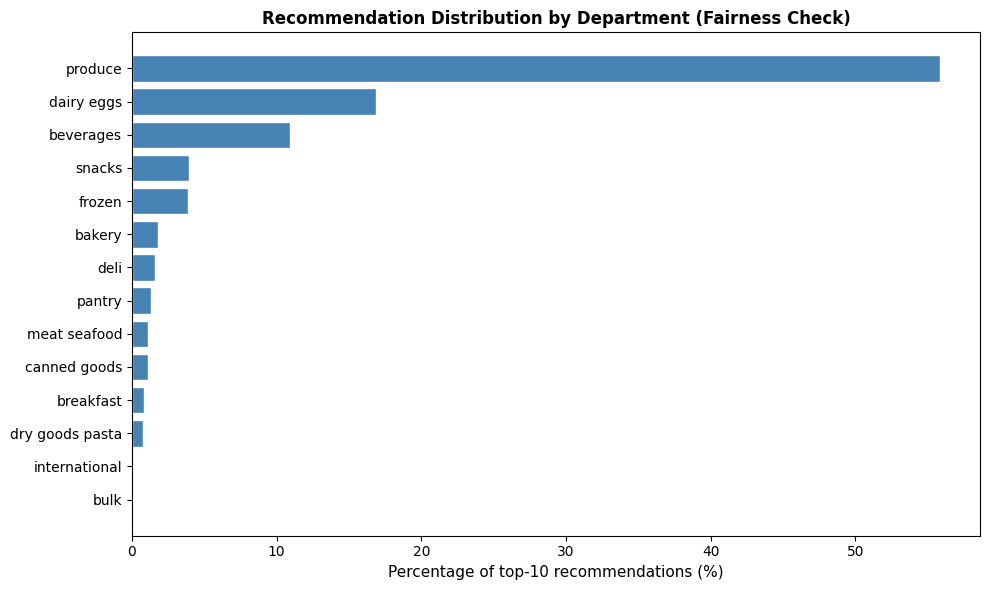

Saved: fairness_chart.png, fairness_summary.json


In [ ]:
if 'all_recommendations' not in dir():
    with open(OUTPUT_DIR / 'recommendations.json', 'r') as fh:
        all_recommendations = json.load(fh)

# Gather all product_ids that appear in any user's top-10 recommendations.
top10_pid_lists = []
for rec_dict in all_recommendations.values():
    for bucket in ('reorder', 'new_for_you'):
        top10_pid_lists.extend([r['product_id'] for r in rec_dict.get(bucket, [])[:10]])

top10_df = pd.DataFrame({'product_id': top10_pid_lists})

# Build a product -> department mapping and join department names.
dept_map = filtered_products[['product_id', 'department_id']].copy()
dept_map = dept_map.merge(
    pd.read_csv(PROCESSED.parent / 'raw' / 'InstaCart Dataset' / 'departments.csv'),
    on='department_id', how='left'
)

# Attach department info to the top-10 product list.
top10_with_dept = top10_df.merge(dept_map, on='product_id', how='left')

# Recommendation share: how many top-10 slots each department occupies.
dept_rec_counts = (
    top10_with_dept.groupby('department')
    .size()
    .reset_index(name='rec_count')
    .sort_values('rec_count', ascending=False)
)
total_top10 = len(top10_pid_lists)
dept_rec_counts['share_pct'] = 100 * dept_rec_counts['rec_count'] / total_top10

print('Recommendation share by department:')
for _, row in dept_rec_counts.iterrows():
    print(f'  {row["department"]:<25}  {row["share_pct"]:>6.2f}%  ({row["rec_count"]:,} recs)')
print()

# Coverage: for each department, what fraction of its products appear in at least one top-10 list.
top10_unique_pids = set(top10_pid_lists)
coverage_rows = []
for dept_id, grp in dept_map.groupby('department_id'):
    dept_name   = grp['department'].iloc[0] if 'department' in grp.columns else str(dept_id)
    total_prods = len(grp)
    covered     = len(set(grp['product_id']) & top10_unique_pids)
    coverage_rows.append({
        'department'      : dept_name,
        'total_products'  : total_prods,
        'covered_products': covered,
        'coverage_pct'    : 100 * covered / total_prods if total_prods > 0 else 0.0,
    })

coverage_df = pd.DataFrame(coverage_rows).sort_values('coverage_pct', ascending=False)
print('Coverage by department (fraction of products appearing in any top-10 list):')
for _, row in coverage_df.iterrows():
    print(f'  {row["department"]:<25}  {row["coverage_pct"]:>6.2f}%'
          f'  ({row["covered_products"]}/{row["total_products"]} products)')
print()

# Plot recommendation share as a horizontal bar chart.
fig, ax = plt.subplots(figsize=(10, 6))
dept_rec_sorted = dept_rec_counts.sort_values('share_pct')
ax.barh(dept_rec_sorted['department'], dept_rec_sorted['share_pct'],
        color='steelblue', edgecolor='white')
ax.set_xlabel('Percentage of top-10 recommendations (%)', fontsize=11)
ax.set_title('Recommendation Distribution by Department (Fairness Check)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fairness_chart.png', dpi=150)
plt.show()

fairness_summary = {
    'recommendation_share': dept_rec_counts.to_dict(orient='records'),
    'coverage'            : coverage_df.to_dict(orient='records'),
}
with open(OUTPUT_DIR / 'fairness_summary.json', 'w', encoding='utf-8') as fh:
    json.dump(fairness_summary, fh, indent=2, default=str)
print('Saved: fairness_chart.png, fairness_summary.json')

## Section 12 — Final Evaluation on Held-Out Test Set

Evaluates against `filtered_train`, which contains one held-out order per user that was never seen during preprocessing, validation construction, or grid search tuning. Full product scoring is used here rather than the candidate-restricted subset used at inference time.

In [ ]:
# Load the orders table to recover user_id for each order_id in filtered_train.
orders = pd.read_csv(DRIVE_ROOT / 'data' / 'Task 1' / 'raw' / 'InstaCart Dataset' / 'orders.csv')

# Join user_id onto filtered_train (which only carries order_id and product_id).
filtered_train = filtered_train.merge(
    orders[['order_id', 'user_id']], on='order_id', how='left'
)

if 'best_k' not in dir():
    best_k       = CKPT_PAYLOAD.get('best_k', K_CANDIDATES[1])
    best_weights = tuple(CKPT_PAYLOAD.get('best_weights', [0.4, 0.3, 0.3]))
if 'purchase_history' not in dir():
    train_prior      = pd.read_parquet(OUTPUT_DIR / 'train_prior.parquet')
    purchase_history = build_user_purchase_history(train_prior)
if 'all_neighbour_indices' not in dir():
    all_neighbour_indices = np.load(OUTPUT_DIR / 'neighbour_indices.npy')
    all_neighbour_sims    = np.load(OUTPUT_DIR / 'neighbour_sims.npy')

# Build the test ground truth: for each user, the set of products in their held-out order.
test_truth = {}
for uid, grp in filtered_train.groupby('user_id'):
    if uid in user_to_idx:
        test_truth[uid] = set(grp['product_id'].unique())

print(f'Test users with ground truth : {len(test_truth):,}')

w_freq, w_knn, w_content = best_weights
test_recs = {}

for uid, relevant in test_truth.items():
    uidx   = user_to_idx.get(uid)
    if uidx is None:
        continue
    n_idxs = all_neighbour_indices[uidx, :best_k]
    n_sims  = all_neighbour_sims[uidx, :best_k]
    # Score all products (no candidate restriction) for unbiased evaluation.
    scores  = compute_hybrid_scores(
        uid, uidx, w_freq, w_knn, w_content,
        purchase_history, n_idxs, n_sims,
        user_item_matrix, user_content_profiles_norm,
        product_tfidf_matrix, user_to_idx, product_to_idx,
        all_product_ids, candidate_ids=None
    )
    # Retain only the top-k products needed for evaluation.
    ranked = sorted(scores, key=scores.get, reverse=True)[:max(EVAL_K)]
    test_recs[uid] = ranked

print()
print('Test set evaluation results (held-out, not used for tuning):')
test_metrics = evaluate_recommendations(test_recs, test_truth, EVAL_K)

with open(OUTPUT_DIR / 'test_set_metrics.json', 'w', encoding='utf-8') as fh:
    json.dump(test_metrics, fh, indent=2)
print('Saved: test_set_metrics.json')

save_checkpoint('complete')
CURRENT_STAGE = 'complete'

Test users with ground truth : 102,036

Test set evaluation results (held-out, not used for tuning):
     k   precision      recall        ndcg
  ----------------------------------------
    10      0.2712      0.3289      0.6500
    20      0.1889      0.4222      0.6462
Saved: test_set_metrics.json
Checkpoint saved: stage=complete  timestamp=2026-04-11T10:01:35.856067


## Section 13 — Export Artefacts for FastAPI Serving Layer

Produces `model_summary.json` with all parameters and metrics needed by the serving layer, and prints a manifest confirming every expected output file is present.

In [ ]:
# Reload values from checkpoint/disk if not already in memory.
if 'best_k' not in dir():
    best_k       = CKPT_PAYLOAD.get('best_k', K_CANDIDATES[1])
    best_weights = tuple(CKPT_PAYLOAD.get('best_weights', [0.4, 0.3, 0.3]))

# Load test metrics from disk.
_test_metrics_path = OUTPUT_DIR / 'test_set_metrics.json'
_test_metrics = {}
if _test_metrics_path.exists():
    with open(_test_metrics_path) as fh:
        _test_metrics = json.load(fh)

# Load grid search results and extract the best validation metrics.
_grid_path = OUTPUT_DIR / 'grid_search_results.json'
_best_val  = {}
if _grid_path.exists():
    with open(_grid_path) as fh:
        _grid = json.load(fh)
    if _grid:
        _best_val = _grid[0].get('metrics', {})

# Count users with recommendations and compute the reorder/new split.
_rec_path = OUTPUT_DIR / 'recommendations.json'
_n_users_with_recs = 0
_pct_reorder = 0.0
_pct_new     = 0.0
if _rec_path.exists():
    with open(_rec_path) as fh:
        _recs = json.load(fh)
    _n_users_with_recs = len(_recs)
    _total_reorder = sum(len(v.get('reorder', []))     for v in _recs.values())
    _total_new     = sum(len(v.get('new_for_you', [])) for v in _recs.values())
    _total         = _total_reorder + _total_new
    _pct_reorder   = round(100 * _total_reorder / _total, 2) if _total > 0 else 0.0
    _pct_new       = round(100 - _pct_reorder, 2)

# Assemble the model summary for the FastAPI serving layer.
model_summary = {
    'best_k'                : best_k,
    'best_weights'          : {
        'w_freq'   : best_weights[0],
        'w_knn'    : best_weights[1],
        'w_content': best_weights[2],
    },
    'MIN_KNN_INTERACTIONS'  : MIN_KNN_INTERACTIONS,
    'TOP_N_NEIGHBOURS'      : TOP_N_NEIGHBOURS,
    'TOP_N_OUTPUT'          : TOP_N_OUTPUT,
    'test_set_metrics'      : _test_metrics,
    'best_validation_metrics': _best_val,
    'total_users_with_recs' : _n_users_with_recs,
    'pct_reorder'           : _pct_reorder,
    'pct_new'               : _pct_new,
}

with open(OUTPUT_DIR / 'model_summary.json', 'w', encoding='utf-8') as fh:
    json.dump(model_summary, fh, indent=2)
print('Saved: model_summary.json')
print()

# List every output file the pipeline is expected to produce.
manifest = [
    'neighbour_indices.npy',
    'neighbour_sims.npy',
    'validation_set.json',
    'train_prior.parquet',
    'grid_search_results.json',
    'recommendations.json',
    'explanations.json',
    'fairness_chart.png',
    'fairness_summary.json',
    'test_set_metrics.json',
    'model_summary.json',
    'modelling_checkpoint.json',
]

print('=' * 60)
print('  OUTPUT FILE MANIFEST')
print('=' * 60)
all_present = True
for fname in manifest:
    fpath  = OUTPUT_DIR / fname
    status = 'OK' if fpath.exists() else 'MISSING'
    if status == 'MISSING':
        all_present = False
    print(f'  {status:<8}  {fname}')
print()
if all_present:
    print('All output files present. Ready for FastAPI serving layer.')
else:
    print('WARNING: some output files are missing. Re-run relevant sections.')
print('=' * 60)

Saved: model_summary.json

  OUTPUT FILE MANIFEST
  OK        neighbour_indices.npy
  OK        neighbour_sims.npy
  OK        validation_set.json
  OK        train_prior.parquet
  OK        grid_search_results.json
  OK        recommendations.json
  OK        explanations.json
  OK        fairness_chart.png
  OK        fairness_summary.json
  OK        test_set_metrics.json
  OK        model_summary.json
  OK        modelling_checkpoint.json

All output files present. Ready for FastAPI serving layer.


## Section 14 — Visualisations

Produces four charts saved to `OUTPUT_DIR`: a grid search precision heatmap, a grouped bar chart of evaluation metrics at k=10 and k=20, a pie chart of reorder vs. new recommendations, and SHAP bar charts for five sampled users.

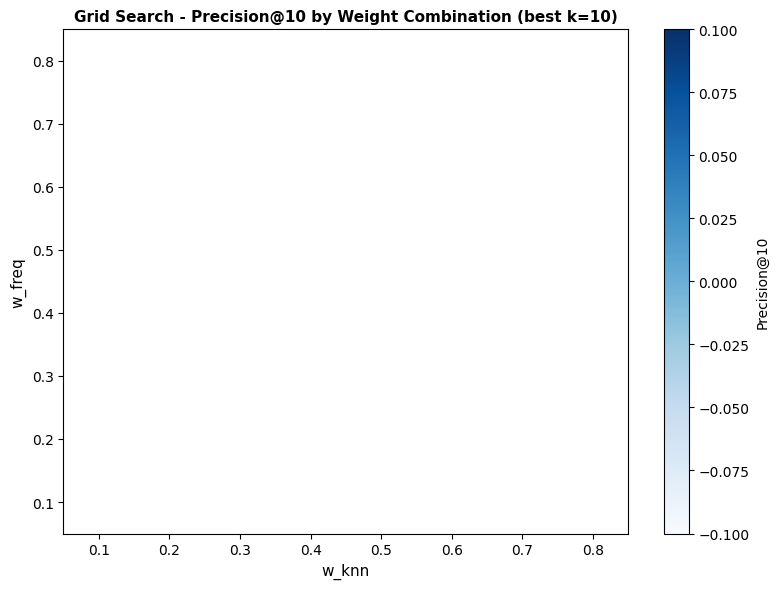

Saved: grid_search_heatmap.png


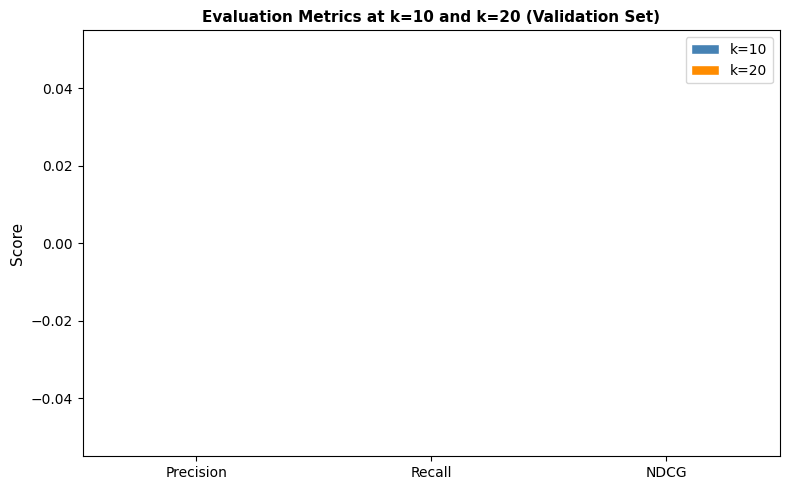

Saved: evaluation_metrics.png


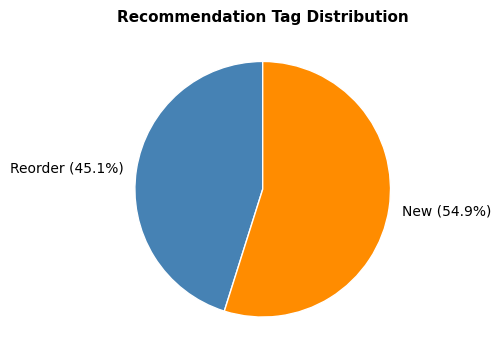

Saved: reorder_vs_new.png


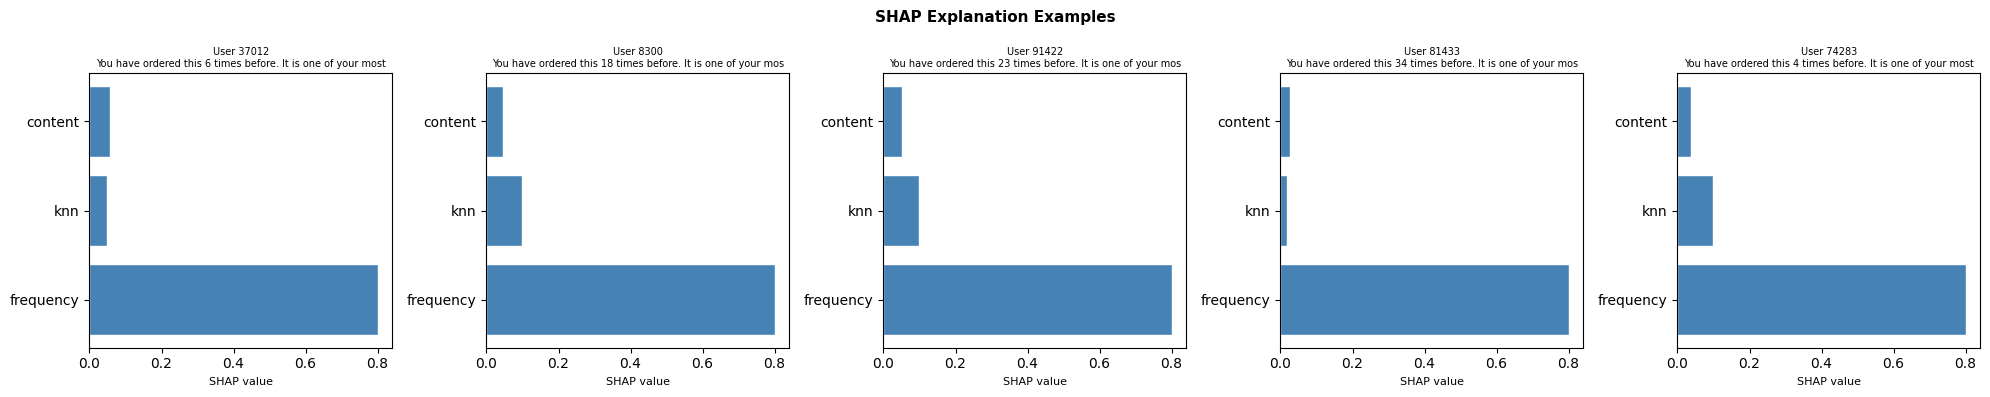

Saved: shap_examples.png


In [ ]:
import random as _rnd
_rnd.seed(RANDOM_SEED)

# -- Chart 1: Grid search heatmap ---------------------------------------------
_grid_path = OUTPUT_DIR / 'grid_search_results.json'
if _grid_path.exists() and 'best_k' in dir():
    with open(_grid_path) as fh:
        _grid_data = json.load(fh)

    # Filter to rows using the best k value, then build a 2-D precision matrix.
    _bk_rows = [r for r in _grid_data if r['k'] == best_k]
    if _bk_rows:
        _wf_vals = sorted(set(r['w_freq'] for r in _bk_rows))
        _wk_vals = sorted(set(r['w_knn']  for r in _bk_rows))
        _heat    = np.full((len(_wf_vals), len(_wk_vals)), np.nan)
        _wf_idx  = {v: i for i, v in enumerate(_wf_vals)}
        _wk_idx  = {v: i for i, v in enumerate(_wk_vals)}
        for r in _bk_rows:
            i = _wf_idx.get(r['w_freq'])
            j = _wk_idx.get(r['w_knn'])
            if i is not None and j is not None:
                _heat[i, j] = r['metrics'].get(10, {}).get('precision', np.nan)

        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(_heat, aspect='auto', origin='lower', cmap='Blues')
        ax.set_xticks(range(len(_wk_vals)))
        ax.set_xticklabels([f'{v:.1f}' for v in _wk_vals])
        ax.set_yticks(range(len(_wf_vals)))
        ax.set_yticklabels([f'{v:.1f}' for v in _wf_vals])
        ax.set_xlabel('w_knn', fontsize=11)
        ax.set_ylabel('w_freq', fontsize=11)
        ax.set_title(f'Grid Search - Precision@10 by Weight Combination (best k={best_k})',
                     fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Precision@10')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'grid_search_heatmap.png', dpi=150)
        plt.show()
        print('Saved: grid_search_heatmap.png')
else:
    print('Grid search results not available; skipping Chart 1.')

# -- Chart 2: Precision/recall/NDCG at k=10 and k=20 -------------------------
_best_val_path = OUTPUT_DIR / 'grid_search_results.json'
if _best_val_path.exists():
    with open(_best_val_path) as fh:
        _gr = json.load(fh)
    # Use the top-ranked result for the validation metric bar chart.
    _bv = _gr[0]['metrics'] if _gr else {}
    _metrics_labels = ['Precision', 'Recall', 'NDCG']
    _metric_keys    = ['precision', 'recall', 'ndcg']
    _k10 = [_bv.get(10, {}).get(mk, 0.0) for mk in _metric_keys]
    _k20 = [_bv.get(20, {}).get(mk, 0.0) for mk in _metric_keys]

    x    = np.arange(len(_metrics_labels))
    w    = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - w/2, _k10, w, label='k=10', color='steelblue',  edgecolor='white')
    ax.bar(x + w/2, _k20, w, label='k=20', color='darkorange', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(_metrics_labels)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Evaluation Metrics at k=10 and k=20 (Validation Set)',
                 fontsize=11, fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'evaluation_metrics.png', dpi=150)
    plt.show()
    print('Saved: evaluation_metrics.png')

# -- Chart 3: Reorder vs new split --------------------------------------------
_rec_path = OUTPUT_DIR / 'recommendations.json'
if _rec_path.exists():
    with open(_rec_path) as fh:
        _recs = json.load(fh)
    # Count total reorder and new recommendations across all users.
    _total_reorder = sum(len(v.get('reorder', []))     for v in _recs.values())
    _total_new     = sum(len(v.get('new_for_you', [])) for v in _recs.values())
    _total   = _total_reorder + _total_new
    _reorder = _total_reorder
    _new     = _total_new
    _sizes   = [_reorder, _new]
    _labels  = [f'Reorder ({100*_reorder/_total:.1f}%)',
                f'New ({100*_new/_total:.1f}%)']
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(_sizes, labels=_labels, colors=['steelblue', 'darkorange'],
           startangle=90, wedgeprops={'edgecolor': 'white'})
    ax.set_title('Recommendation Tag Distribution', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'reorder_vs_new.png', dpi=150)
    plt.show()
    print('Saved: reorder_vs_new.png')

# -- Chart 4: SHAP examples for 5 random users --------------------------------
_expl_path = OUTPUT_DIR / 'explanations.json'
if _expl_path.exists():
    with open(_expl_path) as fh:
        _all_expls = json.load(fh)
    # Sample 5 users at random for the SHAP illustration panel.
    _sample_uids = _rnd.sample(list(_all_expls.keys()), min(5, len(_all_expls)))
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for ax, suid in zip(axes, _sample_uids):
        # Combine reorder and new buckets; use the first available recommendation.
        _buckets = _all_expls.get(suid, {})
        _flat    = _buckets.get('reorder', []) + _buckets.get('new_for_you', [])
        if not _flat:
            ax.axis('off')
            continue
        ex = _flat[0]
        signals = ['frequency', 'knn', 'content']
        vals    = [ex[s] for s in signals]
        colours = ['steelblue' if v >= 0 else 'tomato' for v in vals]
        ax.barh(signals, vals, color=colours, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.6)
        _title = f'User {suid}\n{ex["explanation_text"][:60]}'
        ax.set_title(_title, fontsize=7, wrap=True)
        ax.set_xlabel('SHAP value', fontsize=8)
    plt.suptitle('SHAP Explanation Examples', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_examples.png', dpi=150)
    plt.show()
    print('Saved: shap_examples.png')